In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

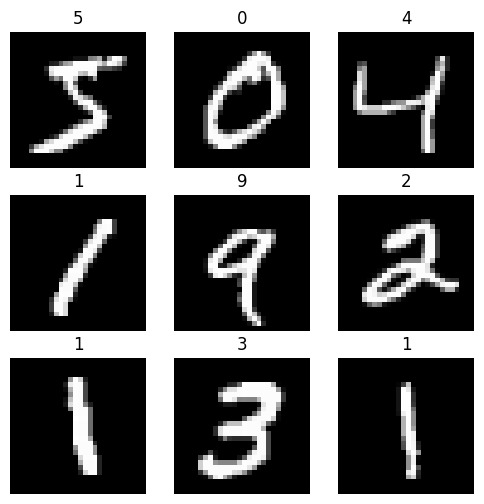

In [4]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [5]:
model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 [==============================] - 17s 9ms/step - loss: 0.2537 - accuracy: 0.9263 - val_loss: 0.1028 - val_accuracy: 0.9708
Epoch 2/10
1688/1688 [==============================] - 18s 10ms/step - loss: 0.1073 - accuracy: 0.9675 - val_loss: 0.0983 - val_accuracy: 0.9688
Epoch 3/10
1688/1688 [==============================] - 15s 9ms/step - loss: 0.0733 - accuracy: 0.9776 - val_loss: 0.0862 - val_accuracy: 0.9723
Epoch 4/10
1688/1688 [==============================] - 15s 9ms/step - loss: 0.0563 - accuracy: 0.9818 - val_loss: 0.0811 - val_accuracy: 0.9757
Epoch 5/10
1688/1688 [==============================] - 19s 11ms/step - loss: 0.0441 - accuracy: 0.9855 - val_loss: 0.0769 - val_accuracy: 0.9797
Epoch 6/10
1688/1688 [==============================] - 16s 10ms/step - loss: 0.0358 - accuracy: 0.9881 - val_loss: 0.0760 - val_accuracy: 0.9785
Epoch 7/10
1688/1688 [==============================] - 9s 5ms/step - loss: 0.0306 - accuracy: 0.9904 - val_loss: 0.0918 - val_

In [8]:
loss, accuracy = model.evaluate(X_test,y_test)

print("Test Accuracy:",accuracy)

313/313 [==============================] - 1s 3ms/step - loss: 0.0961 - accuracy: 0.9762
Test Accuracy: 0.9761999845504761


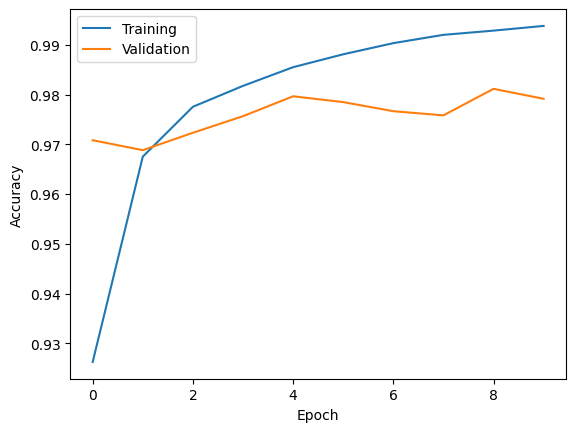

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])
plt.show()

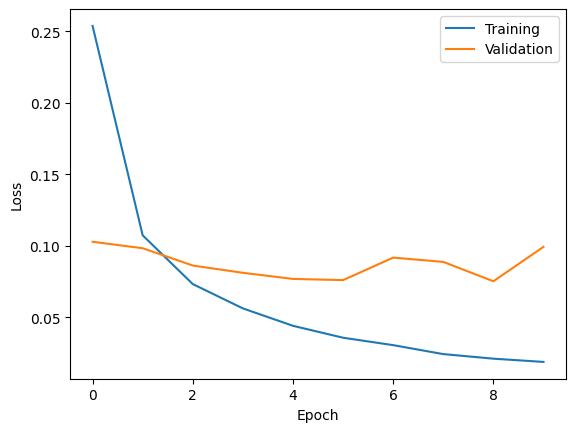

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training","Validation"])
plt.show()

In [11]:
dropout_model = keras.Sequential([
    layers.Flatten(input_shape=(28,28)),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

dropout_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_dropout = dropout_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

dropout_loss, dropout_acc = dropout_model.evaluate(X_test,y_test)

Epoch 1/10
1688/1688 [==============================] - 11s 6ms/step - loss: 0.3275 - accuracy: 0.9016 - val_loss: 0.1293 - val_accuracy: 0.9628
Epoch 2/10
1688/1688 [==============================] - 9s 6ms/step - loss: 0.1656 - accuracy: 0.9497 - val_loss: 0.0865 - val_accuracy: 0.9727
Epoch 3/10
1688/1688 [==============================] - 10s 6ms/step - loss: 0.1310 - accuracy: 0.9601 - val_loss: 0.0804 - val_accuracy: 0.9757
Epoch 4/10
1688/1688 [==============================] - 8s 4ms/step - loss: 0.1127 - accuracy: 0.9651 - val_loss: 0.0729 - val_accuracy: 0.9802
Epoch 5/10
1688/1688 [==============================] - 9s 5ms/step - loss: 0.1004 - accuracy: 0.9684 - val_loss: 0.0760 - val_accuracy: 0.9797
Epoch 6/10
1688/1688 [==============================] - 10s 6ms/step - loss: 0.0910 - accuracy: 0.9712 - val_loss: 0.0770 - val_accuracy: 0.9785
Epoch 7/10
1688/1688 [==============================] - 11s 7ms/step - loss: 0.0835 - accuracy: 0.9727 - val_loss: 0.0720 - val_accur

In [12]:
learning_rates = [0.1,0.01,0.001]

In [13]:
results=[]

for lr in learning_rates:

    model = keras.Sequential([
        layers.Flatten(input_shape=(28,28)),
        layers.Dense(128,activation='relu'),
        layers.Dense(64,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])

    optimizer=keras.optimizers.Adam(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        verbose=0
    )

    loss,acc=model.evaluate(X_test,y_test,verbose=0)

    results.append([lr,acc])

pd.DataFrame(results,columns=["Learning Rate","Accuracy"])

,Learning Rate,Accuracy
0,0.100,0.1135
1,0.010,0.9586
2,0.001,0.9753


In [14]:
batch_sizes=[16,32,64]

batch_results=[]

for batch in batch_sizes:

    model=keras.Sequential([
        layers.Flatten(input_shape=(28,28)),
        layers.Dense(128,activation='relu'),
        layers.Dense(64,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=batch,
        verbose=0
    )

    loss,acc=model.evaluate(X_test,y_test,verbose=0)

    batch_results.append([batch,acc])

pd.DataFrame(batch_results,columns=["Batch Size","Accuracy"])

,Batch Size,Accuracy
0,16,0.9784
1,32,0.9703
2,64,0.9767


In [15]:
(X_train, y_train), (X_test, y_test)=keras.datasets.fashion_mnist.load_data()

X_train=X_train/255.0
X_test=X_test/255.0

4422102/4422102 [==============================] - 1s 0us/step


In [18]:
(X_train, y_train), (X_test, y_test)=keras.datasets.cifar10.load_data()

X_train=X_train/255.0
X_test=X_test/255.0

170498071/170498071 [==============================] - 2634s 15us/step


In [19]:
model=keras.Sequential([
    layers.Flatten(input_shape=(32,32,3)),
    layers.Dense(256,activation='relu'),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

In [17]:
import os
import shutil

cache_dir = os.path.expanduser("~/.keras/datasets")

if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

print("Keras cache deleted.")

Keras cache deleted.


In [20]:
model.summary()

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_9 (Flatten)         (None, 3072)              0         
                                                                 
 dense_27 (Dense)            (None, 256)               786688    
                                                                 
 dense_28 (Dense)            (None, 128)               32896     
                                                                 
 dense_29 (Dense)            (None, 10)                1290      
                                                                 
Total params: 820,874
Trainable params: 820,874
Non-trainable params: 0
_________________________________________________________________
